# 05 — Linear Regression

This notebook builds our required **linear regression** model for hourly RDU temperature forecasting.

It is intentionally designed around the evaluation discipline we established in the preprocessing notebook:

- **2021–2023:** training
- **2024:** validation / model selection
- **2025:** untouched historical test
- **2026:** final assignment forecast

## What this notebook compares

We do not assume one linear specification is best. We compare a small set of defensible ordinary least-squares models on **2024 only**:

1. GFS temperature only
2. Direct regression with time / horizon / recent-observation features
3. Direct regression with additional meteorological features
4. Residual correction: predict GFS error, then add the correction back to raw GFS

All of these use `sklearn.linear_model.LinearRegression`.

The winning specification is chosen using **2024 validation RMSE**. Only after the specification is frozen do we evaluate it once on 2025.

Finally, we refit that frozen specification on all eligible 2021–2025 labeled data and generate the **336 hourly predictions for Sept. 17–30, 2026**.

## Inputs

- `data/processed/modeling_historical.csv`
- `data/processed/modeling_future.csv`
- `data/processed/modeling_feature_manifest.json`

## Outputs

- `data/processed/linear_regression_validation_results.csv`
- `data/processed/linear_regression_test_results.csv`
- `data/processed/linear_regression_2026_predictions.csv`
- `data/processed/linear_regression_final_coefficients.csv`

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

## 1. Locate project files

In [2]:
def find_project_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]

    for candidate in candidates:
        if (
            candidate / "data" / "processed" / "modeling_historical.csv"
        ).exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not find data/processed/modeling_historical.csv. "
        "Run 04_eda_and_build_modeling_data.ipynb first."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

HISTORICAL_PATH = PROCESSED_DIR / "modeling_historical.csv"
FUTURE_PATH = PROCESSED_DIR / "modeling_future.csv"
MANIFEST_PATH = PROCESSED_DIR / "modeling_feature_manifest.json"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)

Project root: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU
Processed directory: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed


In [3]:
historical = pd.read_csv(
    HISTORICAL_PATH,
    parse_dates=[
        "gfs_init_utc",
        "valid_time_utc",
        "valid_time_local",
        "simulated_cutoff_utc",
    ],
)

future = pd.read_csv(
    FUTURE_PATH,
    parse_dates=[
        "gfs_init_utc",
        "valid_time_utc",
        "valid_time_local",
        "simulated_cutoff_utc",
    ],
)

with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

TARGET = manifest["target"]
ALL_MODEL_FEATURES = manifest["model_features"]

print("Historical shape:", historical.shape)
print("Future shape:", future.shape)
print("Target:", TARGET)
print("Available model features:", len(ALL_MODEL_FEATURES))

Historical shape: (13237, 44)
Future shape: (336, 43)
Target: actual_temp_f
Available model features: 32


## 2. Sanity checks and locked splits

In [4]:
expected_splits = {"train", "validation", "test"}

if set(historical["split"].unique()) != expected_splits:
    raise RuntimeError(
        f"Unexpected historical splits: {historical['split'].unique()}"
    )

train = historical[
    historical["split"] == "train"
].copy()

validation = historical[
    historical["split"] == "validation"
].copy()

test = historical[
    historical["split"] == "test"
].copy()

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)
print("Future:", future.shape)

assert future["split"].eq("forecast_2026").all()
assert len(future) == 336

# Check that no target accidentally exists in the future file.
assert TARGET not in future.columns

# Modeling inputs must be complete.
assert historical[ALL_MODEL_FEATURES].isna().sum().sum() == 0
assert future[ALL_MODEL_FEATURES].isna().sum().sum() == 0
assert historical[TARGET].isna().sum() == 0

print("PASS: split and missingness checks succeeded.")

Train: (8064, 44)
Validation: (2688, 44)
Test: (2485, 44)
Future: (336, 43)
PASS: split and missingness checks succeeded.


## 3. Evaluation helpers

We track:

- **RMSE** — primary model-selection metric
- **MAE** — easy to interpret in °F
- **Bias** — mean signed prediction error
- **R²** — descriptive fit metric

We also calculate metrics **per forecast run**. The weekly forecast windows overlap, so performance across forecast origins is more informative than treating every hourly row as fully independent evidence.

In [5]:
def metrics_from_arrays(y_true, y_pred):
    error = np.asarray(y_pred) - np.asarray(y_true)

    return {
        "n": len(y_true),
        "RMSE_F": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "MAE_F": mean_absolute_error(
            y_true, y_pred
        ),
        "Bias_F": error.mean(),
        "R2": r2_score(
            y_true, y_pred
        ),
    }


def metrics_table(frame, prediction_column):
    return pd.Series(
        metrics_from_arrays(
            frame[TARGET],
            frame[prediction_column],
        )
    )


def per_run_metrics(frame, prediction_column):
    rows = []

    for init_time, group in frame.groupby(
        "gfs_init_utc",
        sort=True
    ):
        metrics = metrics_from_arrays(
            group[TARGET],
            group[prediction_column],
        )

        rows.append({
            "gfs_init_utc": init_time,
            **metrics,
        })

    return pd.DataFrame(rows)


def print_model_metrics(frame, prediction_column, label):
    pooled = metrics_table(
        frame,
        prediction_column,
    )

    per_run = per_run_metrics(
        frame,
        prediction_column,
    )

    print(label)
    print(
        f"  Pooled RMSE: {pooled['RMSE_F']:.3f} °F"
    )
    print(
        f"  Pooled MAE:  {pooled['MAE_F']:.3f} °F"
    )
    print(
        f"  Bias:        {pooled['Bias_F']:.3f} °F"
    )
    print(
        f"  R²:          {pooled['R2']:.4f}"
    )
    print(
        f"  Mean run RMSE: {per_run['RMSE_F'].mean():.3f} °F"
    )

    return pooled, per_run

## 4. Raw GFS baseline — train and validation only

In [6]:
for frame in [train, validation]:
    frame["pred_raw_gfs"] = frame["gfs_temp_f"]

train_raw_metrics, _ = print_model_metrics(
    train,
    "pred_raw_gfs",
    "Raw GFS — training years",
)

validation_raw_metrics, validation_raw_runs = print_model_metrics(
    validation,
    "pred_raw_gfs",
    "Raw GFS — validation year (2024)",
)

Raw GFS — training years
  Pooled RMSE: 6.341 °F
  Pooled MAE:  4.699 °F
  Bias:        -0.622 °F
  R²:          0.4888
  Mean run RMSE: 6.126 °F
Raw GFS — validation year (2024)
  Pooled RMSE: 6.363 °F
  Pooled MAE:  4.907 °F
  Bias:        -1.497 °F
  R²:          0.3446
  Mean run RMSE: 6.229 °F


The required linear regression should be judged against **raw GFS**, not merely against a climatology baseline. If a learned correction cannot reliably improve the numerical weather forecast, its additional complexity is not earning its keep.

## 5. Define a small set of linear-regression candidates

In [7]:
# Keep the direct models relatively non-redundant.
#
# We intentionally avoid feeding every engineered feature into OLS:
# many are deterministic combinations of one another and would make
# coefficient interpretation unnecessarily unstable.

GFS_ONLY_FEATURES = [
    "gfs_temp_f",
]

CORE_DIRECT_FEATURES = [
    "gfs_temp_f",
    "forecast_hour",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "recent_actual_temp_f",
    "recent_24h_mean_f",
    "recent_24h_range_f",
]

WEATHER_DIRECT_FEATURES = [
    *CORE_DIRECT_FEATURES,
    "gfs_relative_humidity_pct",
    "gfs_u10_mps",
    "gfs_v10_mps",
    "gfs_mslp_hpa",
    "gfs_total_cloud_cover_pct",
    "gfs_precip_rate_mm_hr",
]

# For residual correction, we predict:
#
# actual_temp - gfs_temp
#
# and add that correction back to GFS.
RESIDUAL_FEATURES = [
    "gfs_temp_f",
    "forecast_hour",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "gfs_relative_humidity_pct",
    "gfs_u10_mps",
    "gfs_v10_mps",
    "gfs_mslp_hpa",
    "gfs_total_cloud_cover_pct",
    "gfs_precip_rate_mm_hr",
    "recent_actual_temp_f",
    "recent_24h_mean_f",
    "recent_24h_range_f",
]

CANDIDATES = {
    "OLS_GFS_only": {
        "features": GFS_ONLY_FEATURES,
        "target_mode": "direct",
    },
    "OLS_core_direct": {
        "features": CORE_DIRECT_FEATURES,
        "target_mode": "direct",
    },
    "OLS_weather_direct": {
        "features": WEATHER_DIRECT_FEATURES,
        "target_mode": "direct",
    },
    "OLS_residual_correction": {
        "features": RESIDUAL_FEATURES,
        "target_mode": "residual",
    },
}

for name, config in CANDIDATES.items():
    missing = sorted(
        set(config["features"])
        - set(ALL_MODEL_FEATURES)
    )

    if missing:
        raise KeyError(
            f"{name} requests unavailable features: {missing}"
        )

    print(
        f"{name}: "
        f"{len(config['features'])} features, "
        f"mode={config['target_mode']}"
    )

OLS_GFS_only: 1 features, mode=direct
OLS_core_direct: 9 features, mode=direct
OLS_weather_direct: 15 features, mode=direct
OLS_residual_correction: 15 features, mode=residual


## 6. Fit candidate ordinary least-squares models

We standardize the inputs inside a pipeline. Scaling does **not** change the class of model — the estimator is still ordinary least-squares `LinearRegression` — but it improves numerical conditioning and makes the fitted coefficients comparable on a standardized-feature basis.

In [8]:
def build_ols_pipeline():
    return Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "model",
            LinearRegression(),
        ),
    ])


def fit_candidate(train_frame, config):
    features = config["features"]
    mode = config["target_mode"]

    model = build_ols_pipeline()

    X_train = train_frame[features]

    if mode == "direct":
        y_train = train_frame[TARGET]

    elif mode == "residual":
        y_train = (
            train_frame[TARGET]
            - train_frame["gfs_temp_f"]
        )

    else:
        raise ValueError(
            f"Unknown target mode: {mode}"
        )

    model.fit(
        X_train,
        y_train,
    )

    return model


def predict_candidate(model, frame, config):
    features = config["features"]
    mode = config["target_mode"]

    raw_prediction = model.predict(
        frame[features]
    )

    if mode == "direct":
        return raw_prediction

    if mode == "residual":
        return (
            frame["gfs_temp_f"].to_numpy()
            + raw_prediction
        )

    raise ValueError(
        f"Unknown target mode: {mode}"
    )

In [9]:
candidate_models = {}
validation_predictions = validation.copy()

validation_rows = []

for name, config in CANDIDATES.items():
    model = fit_candidate(
        train,
        config,
    )

    candidate_models[name] = model

    prediction_column = f"pred_{name}"

    validation_predictions[
        prediction_column
    ] = predict_candidate(
        model,
        validation,
        config,
    )

    pooled = metrics_table(
        validation_predictions,
        prediction_column,
    )

    run_metrics = per_run_metrics(
        validation_predictions,
        prediction_column,
    )

    validation_rows.append({
        "model": name,
        "n_features": len(
            config["features"]
        ),
        "target_mode": config["target_mode"],
        **pooled.to_dict(),
        "mean_run_RMSE_F": run_metrics["RMSE_F"].mean(),
        "median_run_RMSE_F": run_metrics["RMSE_F"].median(),
        "worst_run_RMSE_F": run_metrics["RMSE_F"].max(),
    })

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values(
        ["RMSE_F", "MAE_F"]
    )
    .reset_index(drop=True)
)

display(
    validation_results.round(4)
)

,model,n_features,target_mode,n,RMSE_F,MAE_F,Bias_F,R2,mean_run_RMSE_F,median_run_RMSE_F,worst_run_RMSE_F
0,OLS_GFS_only,1,direct,2688.0,5.3511,4.0578,-0.3052,0.5365,5.2258,5.1931,7.8870
1,OLS_weather_direct,15,direct,2688.0,5.7279,4.5231,0.1001,0.4689,5.5651,4.9659,8.2336
2,OLS_residual_correction,15,residual,2688.0,5.7279,4.5231,0.1001,0.4689,5.5651,4.9659,8.2336
3,OLS_core_direct,9,direct,2688.0,5.7476,4.5872,-0.1109,0.4652,5.5859,4.9547,8.2294


## 7. Compare candidates against raw GFS on 2024

In [10]:
raw_row = {
    "model": "Raw_GFS",
    "n_features": 1,
    "target_mode": "none",
    **validation_raw_metrics.to_dict(),
    "mean_run_RMSE_F": validation_raw_runs["RMSE_F"].mean(),
    "median_run_RMSE_F": validation_raw_runs["RMSE_F"].median(),
    "worst_run_RMSE_F": validation_raw_runs["RMSE_F"].max(),
}

validation_comparison = pd.concat(
    [
        pd.DataFrame([raw_row]),
        validation_results,
    ],
    ignore_index=True,
)

validation_comparison = (
    validation_comparison
    .sort_values(
        ["RMSE_F", "MAE_F"]
    )
    .reset_index(drop=True)
)

display(
    validation_comparison.round(4)
)

,model,n_features,target_mode,n,RMSE_F,MAE_F,Bias_F,R2,mean_run_RMSE_F,median_run_RMSE_F,worst_run_RMSE_F
0,OLS_GFS_only,1,direct,2688.0,5.3511,4.0578,-0.3052,0.5365,5.2258,5.1931,7.8870
1,OLS_weather_direct,15,direct,2688.0,5.7279,4.5231,0.1001,0.4689,5.5651,4.9659,8.2336
2,OLS_residual_correction,15,residual,2688.0,5.7279,4.5231,0.1001,0.4689,5.5651,4.9659,8.2336
3,OLS_core_direct,9,direct,2688.0,5.7476,4.5872,-0.1109,0.4652,5.5859,4.9547,8.2294
4,Raw_GFS,1,none,2688.0,6.3628,4.9068,-1.4968,0.3446,6.2290,6.1219,8.4388


In [11]:
VAL_RESULTS_PATH = (
    PROCESSED_DIR
    / "linear_regression_validation_results.csv"
)

validation_comparison.to_csv(
    VAL_RESULTS_PATH,
    index=False,
)

print("Saved:", VAL_RESULTS_PATH)

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/linear_regression_validation_results.csv


## 8. Freeze the winning linear-regression specification

The specification is selected **only from 2024 validation performance**.

After this cell, do not change the feature set based on what happens on 2025.

In [12]:
FINAL_MODEL_NAME = (
    validation_results
    .iloc[0]["model"]
)

FINAL_CONFIG = CANDIDATES[
    FINAL_MODEL_NAME
]

print("Frozen model:", FINAL_MODEL_NAME)
print("Target mode:", FINAL_CONFIG["target_mode"])
print("Features:")
for feature in FINAL_CONFIG["features"]:
    print(" ", feature)

best_validation_rmse = (
    validation_results
    .iloc[0]["RMSE_F"]
)

raw_validation_rmse = (
    validation_raw_metrics["RMSE_F"]
)

improvement = (
    raw_validation_rmse
    - best_validation_rmse
)

improvement_pct = (
    100
    * improvement
    / raw_validation_rmse
)

print(
    f"\nValidation RMSE improvement vs raw GFS: "
    f"{improvement:.3f} °F "
    f"({improvement_pct:.2f}%)"
)

Frozen model: OLS_GFS_only
Target mode: direct
Features:
  gfs_temp_f

Validation RMSE improvement vs raw GFS: 1.012 °F (15.90%)


## 9. Validation residual diagnostics for the frozen model

In [13]:
frozen_validation_column = (
    f"pred_{FINAL_MODEL_NAME}"
)

validation_predictions[
    "frozen_error_f"
] = (
    validation_predictions[
        frozen_validation_column
    ]
    - validation_predictions[TARGET]
)

validation_predictions[
    "frozen_abs_error_f"
] = validation_predictions[
    "frozen_error_f"
].abs()

validation_run_metrics = per_run_metrics(
    validation_predictions,
    frozen_validation_column,
)

display(
    validation_run_metrics.round(3)
)

,gfs_init_utc,n,RMSE_F,MAE_F,Bias_F,R2
0,2024-07-29 18:00:00+00:00,336,4.662,3.548,-0.178,0.347
1,2024-08-05 18:00:00+00:00,336,5.229,4.029,-1.226,0.236
2,2024-08-12 18:00:00+00:00,336,7.887,6.209,2.414,0.190
3,2024-08-19 18:00:00+00:00,336,5.243,4.127,0.586,0.692
4,2024-08-26 18:00:00+00:00,336,4.874,3.711,-0.196,0.709
5,2024-09-02 18:00:00+00:00,336,5.157,4.087,0.013,0.417
6,2024-09-09 18:00:00+00:00,336,3.474,2.582,-0.176,0.644
7,2024-09-16 18:00:00+00:00,336,5.280,4.170,-3.678,-0.117


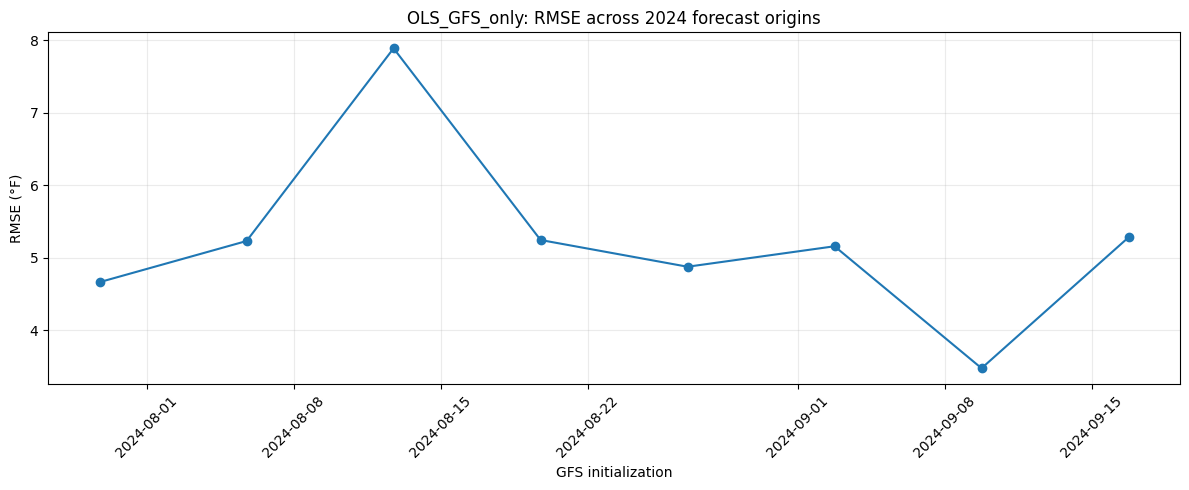

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    validation_run_metrics[
        "gfs_init_utc"
    ],
    validation_run_metrics[
        "RMSE_F"
    ],
    marker="o",
)

plt.title(
    f"{FINAL_MODEL_NAME}: RMSE across 2024 forecast origins"
)
plt.xlabel("GFS initialization")
plt.ylabel("RMSE (°F)")
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

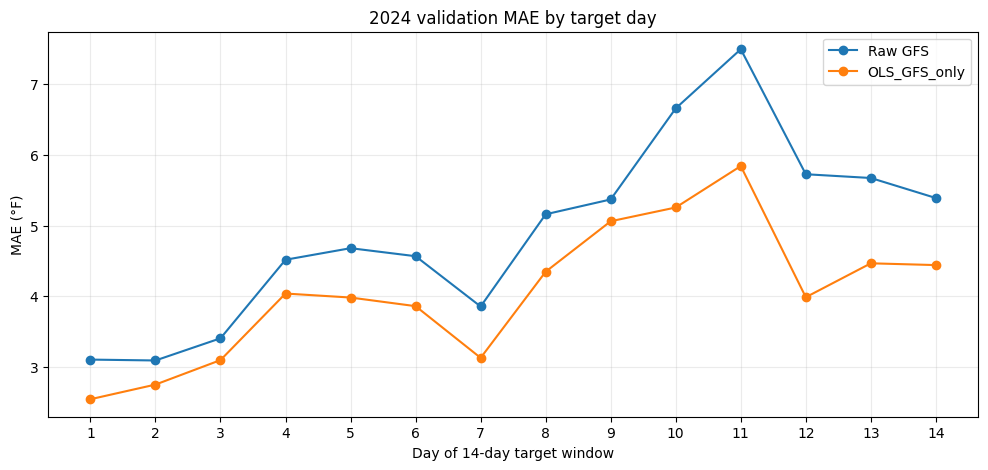

In [15]:
lead_error = (
    validation_predictions
    .groupby("target_day")
    ["frozen_abs_error_f"]
    .mean()
)

raw_lead_error = (
    validation_predictions
    .assign(
        raw_abs_error=lambda d: (
            d["gfs_temp_f"]
            - d[TARGET]
        ).abs()
    )
    .groupby("target_day")
    ["raw_abs_error"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    raw_lead_error.index,
    raw_lead_error.values,
    marker="o",
    label="Raw GFS",
)

plt.plot(
    lead_error.index,
    lead_error.values,
    marker="o",
    label=FINAL_MODEL_NAME,
)

plt.title(
    "2024 validation MAE by target day"
)
plt.xlabel("Day of 14-day target window")
plt.ylabel("MAE (°F)")
plt.xticks(range(1, 15))
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 10. Inspect standardized coefficients

Because the inputs are standardized before regression, the coefficient magnitudes below are on a comparable feature scale.

For the residual-correction model, coefficients describe the learned **GFS error correction** rather than temperature directly.

In [16]:
frozen_train_model = candidate_models[
    FINAL_MODEL_NAME
]

linear_model = frozen_train_model.named_steps[
    "model"
]

coefficient_table = pd.DataFrame({
    "feature": FINAL_CONFIG["features"],
    "standardized_coefficient": linear_model.coef_,
})

coefficient_table[
    "abs_standardized_coefficient"
] = coefficient_table[
    "standardized_coefficient"
].abs()

coefficient_table = (
    coefficient_table
    .sort_values(
        "abs_standardized_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    coefficient_table.round(4)
)

,feature,standardized_coefficient,abs_standardized_coefficient
0,gfs_temp_f,6.7938,6.7938


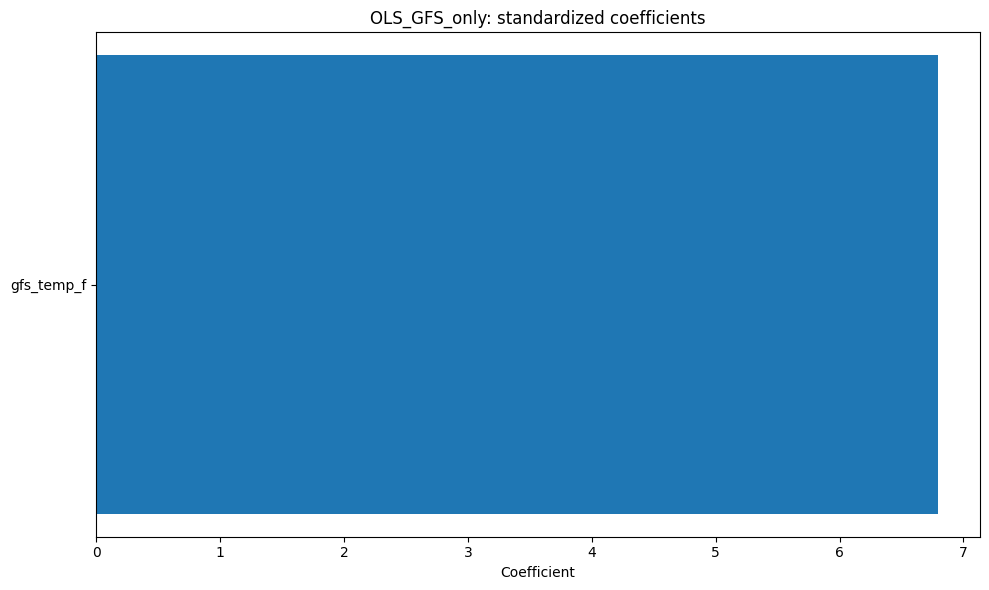

In [17]:
plt.figure(figsize=(10, 6))

plot_coefficients = (
    coefficient_table
    .sort_values(
        "standardized_coefficient"
    )
)

plt.barh(
    plot_coefficients["feature"],
    plot_coefficients[
        "standardized_coefficient"
    ],
)

plt.title(
    f"{FINAL_MODEL_NAME}: standardized coefficients"
)
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

# 11. Unlock the 2025 historical test set

Everything above used only 2021–2024 to make modeling decisions.

The model specification is now frozen. We evaluate it **once** on 2025 and compare it against raw GFS.

In [18]:
# Fit the frozen specification on all development data:
# 2021–2024.

development = historical[
    historical["split"].isin(
        ["train", "validation"]
    )
].copy()

frozen_model_for_test = fit_candidate(
    development,
    FINAL_CONFIG,
)

test_predictions = test.copy()

test_predictions["pred_raw_gfs"] = (
    test_predictions["gfs_temp_f"]
)

test_predictions[
    "pred_frozen_ols"
] = predict_candidate(
    frozen_model_for_test,
    test_predictions,
    FINAL_CONFIG,
)

raw_test_metrics, raw_test_runs = print_model_metrics(
    test_predictions,
    "pred_raw_gfs",
    "Raw GFS — 2025 test",
)

ols_test_metrics, ols_test_runs = print_model_metrics(
    test_predictions,
    "pred_frozen_ols",
    f"{FINAL_MODEL_NAME} — 2025 test",
)

Raw GFS — 2025 test
  Pooled RMSE: 6.519 °F
  Pooled MAE:  4.811 °F
  Bias:        2.272 °F
  R²:          0.2802
  Mean run RMSE: 6.383 °F
OLS_GFS_only — 2025 test
  Pooled RMSE: 6.049 °F
  Pooled MAE:  4.614 °F
  Bias:        3.221 °F
  R²:          0.3803
  Mean run RMSE: 5.929 °F


In [19]:
test_results = pd.DataFrame([
    {
        "model": "Raw_GFS",
        **raw_test_metrics.to_dict(),
        "mean_run_RMSE_F": raw_test_runs["RMSE_F"].mean(),
        "median_run_RMSE_F": raw_test_runs["RMSE_F"].median(),
        "worst_run_RMSE_F": raw_test_runs["RMSE_F"].max(),
    },
    {
        "model": FINAL_MODEL_NAME,
        **ols_test_metrics.to_dict(),
        "mean_run_RMSE_F": ols_test_runs["RMSE_F"].mean(),
        "median_run_RMSE_F": ols_test_runs["RMSE_F"].median(),
        "worst_run_RMSE_F": ols_test_runs["RMSE_F"].max(),
    },
])

display(
    test_results.round(4)
)

TEST_RESULTS_PATH = (
    PROCESSED_DIR
    / "linear_regression_test_results.csv"
)

test_results.to_csv(
    TEST_RESULTS_PATH,
    index=False,
)

print("Saved:", TEST_RESULTS_PATH)

,model,n,RMSE_F,MAE_F,Bias_F,R2,mean_run_RMSE_F,median_run_RMSE_F,worst_run_RMSE_F
0,Raw_GFS,2485.0,6.5187,4.8107,2.2724,0.2802,6.3830,6.4596,8.5049
1,OLS_GFS_only,2485.0,6.0485,4.6138,3.2215,0.3803,5.9291,6.0816,8.3204


Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/linear_regression_test_results.csv


### 2025 interpretation

Do not automatically redesign the linear model if the 2025 score is disappointing. That would turn the test set into another validation set.

We may use the result to compare the **already-frozen** linear model with later model families, but the linear-regression specification itself should remain fixed.

## 12. Visualize 2025 test predictions

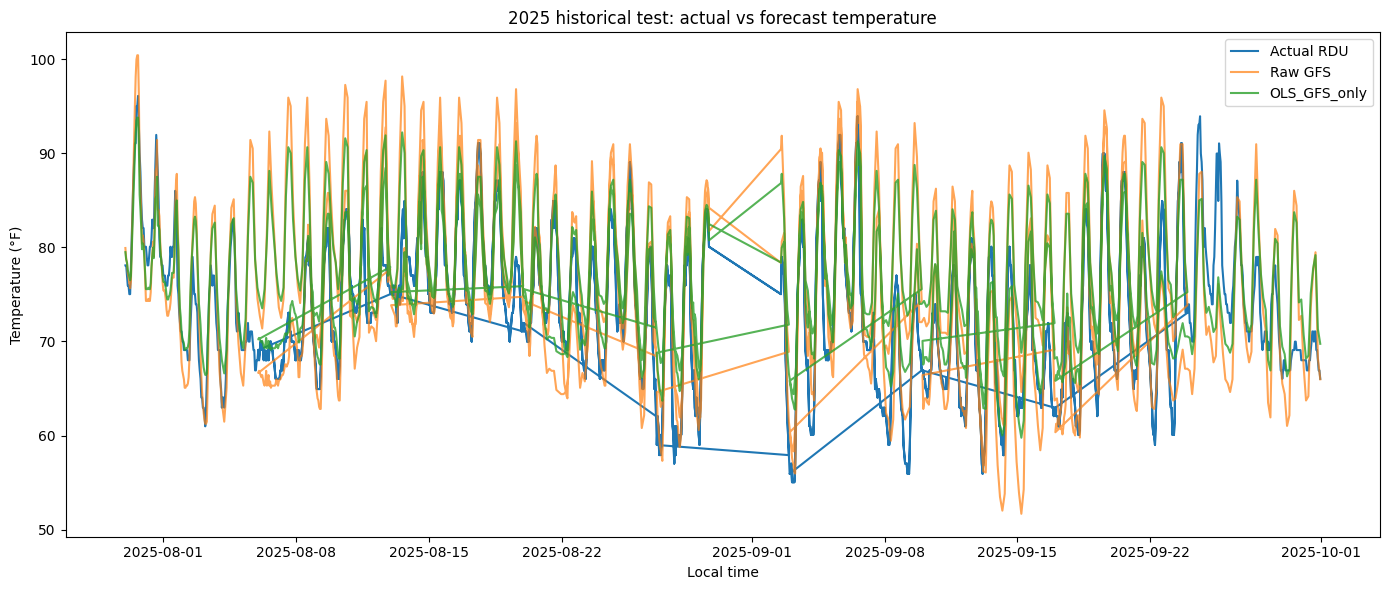

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_predictions["valid_time_local"],
    test_predictions[TARGET],
    label="Actual RDU",
)

plt.plot(
    test_predictions["valid_time_local"],
    test_predictions["pred_raw_gfs"],
    alpha=0.7,
    label="Raw GFS",
)

plt.plot(
    test_predictions["valid_time_local"],
    test_predictions["pred_frozen_ols"],
    alpha=0.8,
    label=FINAL_MODEL_NAME,
)

plt.title(
    "2025 historical test: actual vs forecast temperature"
)
plt.xlabel("Local time")
plt.ylabel("Temperature (°F)")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Refit the frozen model on all 2021–2025 data

At this point, 2025 has served its purpose as the historical test.

For the real 2026 forecast, all 2021–2025 observations were historically available before the assignment cutoff, so we now use all labeled historical rows to estimate the final coefficients.

In [21]:
final_training_data = historical.copy()

final_model = fit_candidate(
    final_training_data,
    FINAL_CONFIG,
)

future_predictions = future.copy()

future_predictions[
    "linear_regression_temp_f"
] = predict_candidate(
    final_model,
    future_predictions,
    FINAL_CONFIG,
)

future_predictions[
    "raw_gfs_temp_f"
] = future_predictions[
    "gfs_temp_f"
]

future_predictions[
    "linear_minus_raw_gfs_f"
] = (
    future_predictions[
        "linear_regression_temp_f"
    ]
    - future_predictions[
        "raw_gfs_temp_f"
    ]
)

assert len(future_predictions) == 336

display(
    future_predictions[
        [
            "valid_time_local",
            "forecast_hour",
            "raw_gfs_temp_f",
            "linear_regression_temp_f",
            "linear_minus_raw_gfs_f",
        ]
    ].head(24)
)

,valid_time_local,forecast_hour,raw_gfs_temp_f,linear_regression_temp_f,linear_minus_raw_gfs_f
0,2026-09-17 00:00:00-04:00,10,69.350,71.559795,2.209795
1,2026-09-17 01:00:00-04:00,11,68.900,71.250304,2.350304
2,2026-09-17 02:00:00-04:00,12,67.325,70.167085,2.842085
3,2026-09-17 03:00:00-04:00,13,66.650,69.702848,3.052848
4,2026-09-17 04:00:00-04:00,14,65.750,69.083866,3.333866
5,2026-09-17 05:00:00-04:00,15,65.075,68.619629,3.544629
6,2026-09-17 06:00:00-04:00,16,64.400,68.155392,3.755392
7,2026-09-17 07:00:00-04:00,17,64.175,68.000647,3.825647
8,2026-09-17 08:00:00-04:00,18,67.550,70.321830,2.771830
9,2026-09-17 09:00:00-04:00,19,72.725,73.880978,1.155978


## 14. Sanity-check the 2026 forecast

In [22]:
future_summary = (
    future_predictions[
        [
            "raw_gfs_temp_f",
            "linear_regression_temp_f",
            "linear_minus_raw_gfs_f",
        ]
    ]
    .describe()
    .T
)

display(
    future_summary.round(3)
)

print(
    "Largest absolute adjustment:",
    future_predictions[
        "linear_minus_raw_gfs_f"
    ].abs().max(),
    "°F",
)

print(
    "Mean adjustment:",
    future_predictions[
        "linear_minus_raw_gfs_f"
    ].mean(),
    "°F",
)

,count,mean,std,min,25%,50%,75%,max
raw_gfs_temp_f,336.0,70.753,7.773,55.512,65.075,70.025,74.338,95.45
linear_regression_temp_f,336.0,72.525,5.346,62.043,68.620,72.024,74.990,89.51
linear_minus_raw_gfs_f,336.0,1.772,2.427,-5.940,0.652,1.999,3.545,6.53


Largest absolute adjustment: 6.530442324716475 °F
Mean adjustment: 1.7716456579028117 °F


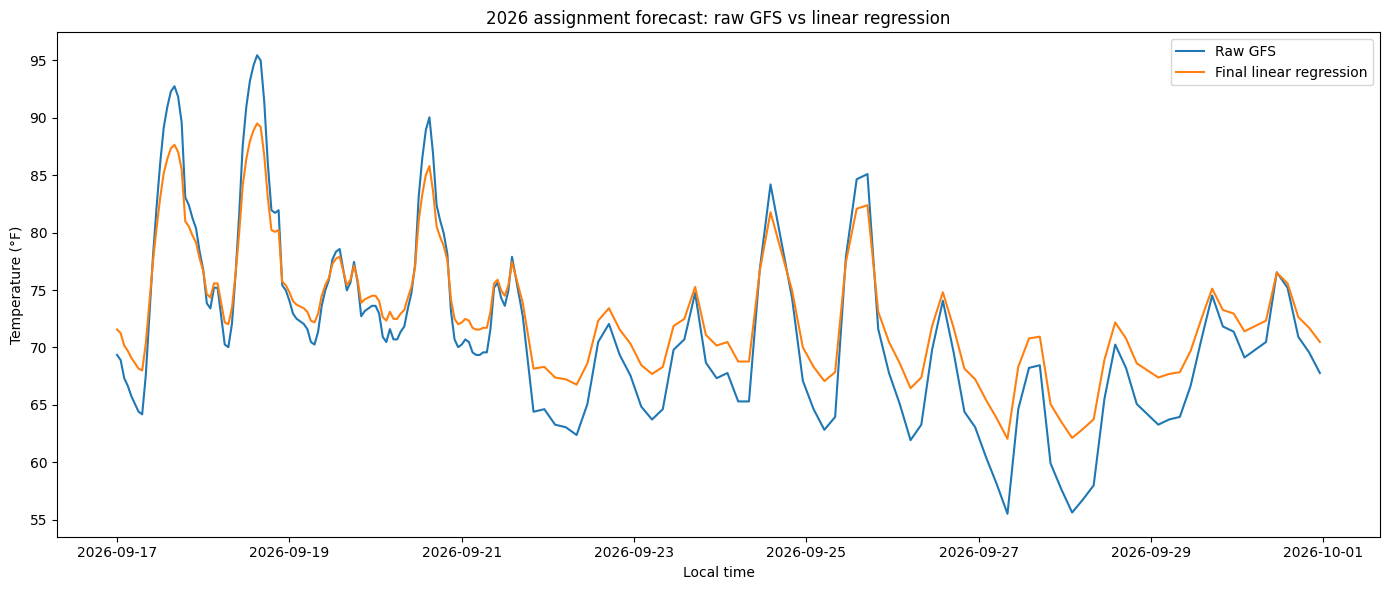

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(
    future_predictions[
        "valid_time_local"
    ],
    future_predictions[
        "raw_gfs_temp_f"
    ],
    label="Raw GFS",
)

plt.plot(
    future_predictions[
        "valid_time_local"
    ],
    future_predictions[
        "linear_regression_temp_f"
    ],
    label="Final linear regression",
)

plt.title(
    "2026 assignment forecast: raw GFS vs linear regression"
)
plt.xlabel("Local time")
plt.ylabel("Temperature (°F)")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Save final 2026 linear-regression predictions

In [24]:
PREDICTIONS_OUTPUT = (
    PROCESSED_DIR
    / "linear_regression_2026_predictions.csv"
)

prediction_output = future_predictions[
    [
        "valid_time_utc",
        "valid_time_local",
        "forecast_hour",
        "target_day",
        "local_hour",
        "raw_gfs_temp_f",
        "linear_regression_temp_f",
        "linear_minus_raw_gfs_f",
    ]
].copy()

prediction_output.to_csv(
    PREDICTIONS_OUTPUT,
    index=False,
)

print("Saved:", PREDICTIONS_OUTPUT)
print("Rows:", len(prediction_output))

display(
    prediction_output.head()
)

display(
    prediction_output.tail()
)

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/linear_regression_2026_predictions.csv
Rows: 336


,valid_time_utc,valid_time_local,forecast_hour,target_day,local_hour,raw_gfs_temp_f,linear_regression_temp_f,linear_minus_raw_gfs_f
0,2026-09-17 04:00:00+00:00,2026-09-17 00:00:00-04:00,10,1,0,69.350,71.559795,2.209795
1,2026-09-17 05:00:00+00:00,2026-09-17 01:00:00-04:00,11,1,1,68.900,71.250304,2.350304
2,2026-09-17 06:00:00+00:00,2026-09-17 02:00:00-04:00,12,1,2,67.325,70.167085,2.842085
3,2026-09-17 07:00:00+00:00,2026-09-17 03:00:00-04:00,13,1,3,66.650,69.702848,3.052848
4,2026-09-17 08:00:00+00:00,2026-09-17 04:00:00-04:00,14,1,4,65.750,69.083866,3.333866


,valid_time_utc,valid_time_local,forecast_hour,target_day,local_hour,raw_gfs_temp_f,linear_regression_temp_f,linear_minus_raw_gfs_f
331,2026-09-30 23:00:00+00:00,2026-09-30 19:00:00-04:00,341,14,19,70.025,72.024032,1.999032
332,2026-10-01 00:00:00+00:00,2026-09-30 20:00:00-04:00,342,14,20,69.575,71.714541,2.139541
333,2026-10-01 01:00:00+00:00,2026-09-30 21:00:00-04:00,343,14,21,68.975,71.301886,2.326886
334,2026-10-01 02:00:00+00:00,2026-09-30 22:00:00-04:00,344,14,22,68.375,70.889231,2.514231
335,2026-10-01 03:00:00+00:00,2026-09-30 23:00:00-04:00,345,14,23,67.775,70.476576,2.701576


## 16. Save final model coefficients

In [25]:
final_linear_estimator = (
    final_model
    .named_steps["model"]
)

final_scaler = (
    final_model
    .named_steps["scale"]
)

FINAL_COEFFICIENTS_OUTPUT = (
    PROCESSED_DIR
    / "linear_regression_final_coefficients.csv"
)

final_coefficients = pd.DataFrame({
    "feature": FINAL_CONFIG["features"],
    "standardized_coefficient": final_linear_estimator.coef_,
    "feature_mean": final_scaler.mean_,
    "feature_scale": final_scaler.scale_,
})

final_coefficients[
    "abs_standardized_coefficient"
] = final_coefficients[
    "standardized_coefficient"
].abs()

final_coefficients = (
    final_coefficients
    .sort_values(
        "abs_standardized_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

final_coefficients.to_csv(
    FINAL_COEFFICIENTS_OUTPUT,
    index=False,
)

print(
    "Final model:",
    FINAL_MODEL_NAME,
)
print(
    "Intercept:",
    final_linear_estimator.intercept_,
)
print(
    "Saved:",
    FINAL_COEFFICIENTS_OUTPUT,
)

display(
    final_coefficients.round(5)
)

Final model: OLS_GFS_only
Intercept: 75.86211226108634
Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/linear_regression_final_coefficients.csv


,feature,standardized_coefficient,feature_mean,feature_scale,abs_standardized_coefficient
0,gfs_temp_f,6.4415,75.60557,9.36593,6.4415


## 17. Final summary

In [26]:
summary = pd.DataFrame([
    {
        "stage": "2024 validation",
        "model": "Raw GFS",
        "RMSE_F": validation_raw_metrics["RMSE_F"],
        "MAE_F": validation_raw_metrics["MAE_F"],
    },
    {
        "stage": "2024 validation",
        "model": FINAL_MODEL_NAME,
        "RMSE_F": (
            validation_results
            .loc[
                validation_results["model"]
                == FINAL_MODEL_NAME,
                "RMSE_F"
            ]
            .iloc[0]
        ),
        "MAE_F": (
            validation_results
            .loc[
                validation_results["model"]
                == FINAL_MODEL_NAME,
                "MAE_F"
            ]
            .iloc[0]
        ),
    },
    {
        "stage": "2025 test",
        "model": "Raw GFS",
        "RMSE_F": raw_test_metrics["RMSE_F"],
        "MAE_F": raw_test_metrics["MAE_F"],
    },
    {
        "stage": "2025 test",
        "model": FINAL_MODEL_NAME,
        "RMSE_F": ols_test_metrics["RMSE_F"],
        "MAE_F": ols_test_metrics["MAE_F"],
    },
])

display(
    summary.round(4)
)

print("\nFrozen linear model:", FINAL_MODEL_NAME)
print("2026 prediction rows:", len(prediction_output))

print(
    "\nLinear-regression workflow complete. "
    "The next modeling notebook should build the nonlinear challenger "
    "(recommended: XGBoost residual correction) using the same locked "
    "train / validation / test discipline."
)

,stage,model,RMSE_F,MAE_F
0,2024 validation,Raw GFS,6.3628,4.9068
1,2024 validation,OLS_GFS_only,5.3511,4.0578
2,2025 test,Raw GFS,6.5187,4.8107
3,2025 test,OLS_GFS_only,6.0485,4.6138



Frozen linear model: OLS_GFS_only
2026 prediction rows: 336

Linear-regression workflow complete. The next modeling notebook should build the nonlinear challenger (recommended: XGBoost residual correction) using the same locked train / validation / test discipline.
